# Phase 6 — Results Analysis

In [1]:
import os
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import sys

# Setup paths
sys.path.append(os.path.abspath("../src"))
from dataset import create_dataloaders
from model import IntentClassifier

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: mps


In [2]:
# Load Checkpoint and Config
checkpoint = torch.load("../models/best_model.pt", map_location=device, weights_only=False)
config = checkpoint["hyperparameters"]
print(f"Loaded model from epoch {checkpoint['epoch']} with validation accuracy {checkpoint['val_accuracy']*100:.2f}%")

# Load Data maps
with open("../data/processed/word2idx.json", "r") as f:
    word2idx = json.load(f)
with open("../data/processed/idx2label.json", "r") as f:
    idx2label = {int(k): v for k, v in json.load(f).items()}
label2idx = {v: k for k, v in idx2label.items()}

# Initialize model
model = IntentClassifier(
    vocab_size=config["vocab_size"],
    embed_dim=config["embed_dim"],
    hidden_size=config["hidden_size"],
    num_layers=config["num_layers"],
    num_classes=len(label2idx),
    dropout=config["dropout"],
    bidirectional=config["bidirectional"],
    pad_idx=word2idx.get("<PAD>", 0)
).to(device)

model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print("Model loaded successfully.")


Loaded model from epoch 8 with validation accuracy 98.14%
Model loaded successfully.


In [3]:
# Run Evaluation on Test Set
_, val_loader, _, _ = create_dataloaders(
    train_dir="../data/raw/train",
    val_dir="../data/raw/test",
    word2idx=word2idx,
    label2idx=label2idx,
    max_seq_len=config["max_seq_len"],
    batch_size=config["batch_size"]
)

all_preds = []
all_labels = []

with torch.no_grad():
    for texts, labels in val_loader:
        texts, labels = texts.to(device), labels.to(device)
        logits = model(texts)
        preds = torch.argmax(logits, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Map indices to names
target_names = [idx2label[i] for i in range(len(idx2label))]

print("Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=target_names))


Classification Report:

                      precision    recall  f1-score   support

       AddToPlaylist       0.97      1.00      0.99       100
      BookRestaurant       0.98      1.00      0.99       100
          GetWeather       0.98      0.98      0.98       100
           PlayMusic       0.98      0.95      0.96       100
            RateBook       1.00      1.00      1.00       100
  SearchCreativeWork       0.96      0.98      0.97       100
SearchScreeningEvent       1.00      0.96      0.98       100

            accuracy                           0.98       700
           macro avg       0.98      0.98      0.98       700
        weighted avg       0.98      0.98      0.98       700



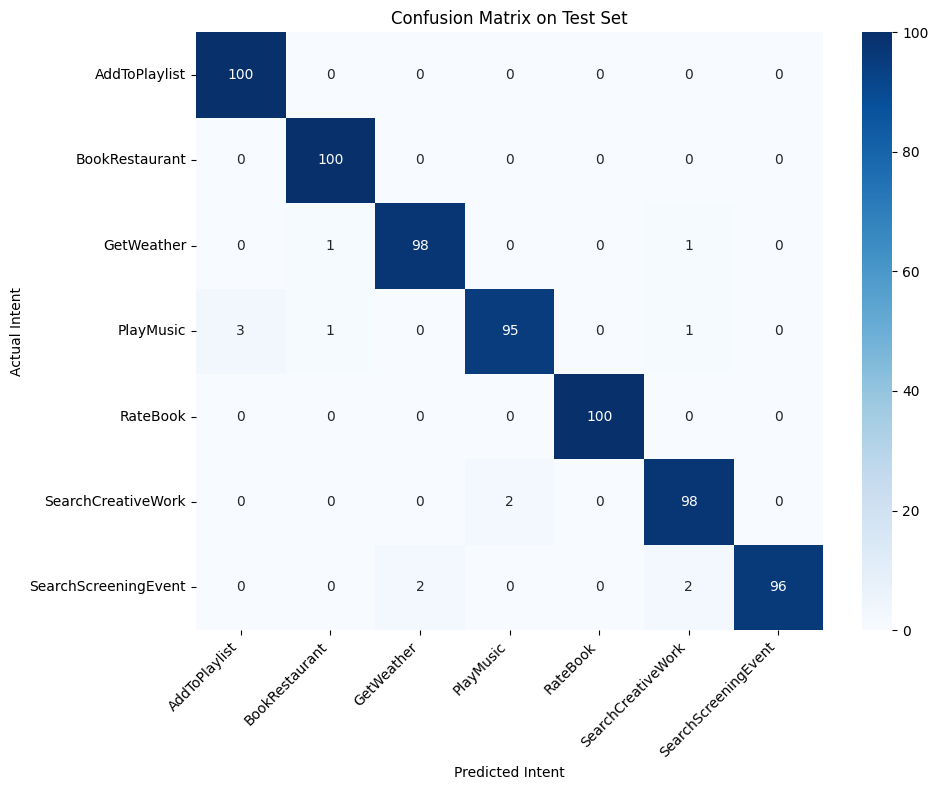

Confusion matrix saved to assets/confusion_matrix.png


In [4]:
# Plot Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix on Test Set')
plt.xlabel('Predicted Intent')
plt.ylabel('Actual Intent')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Save plot
os.makedirs("../assets", exist_ok=True)
plt.savefig("../assets/confusion_matrix.png", dpi=300)
plt.show()
print("Confusion matrix saved to assets/confusion_matrix.png")
